In [1]:
import pandas as pd 
df = pd.read_csv("C:\\Users\\Laptop Valley\\Downloads\\.ipynb_checkpoints\\bank.csv")
print(df.head())
print(df.info())
print(df.describe())
print(df['job'].value_counts())
print(df['marital'].value_counts())
print(df['age'].describe())




   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 

In [5]:
# Suppose the target column is 'deposit'
df['deposit'] = df['deposit'].map({'no':0, 'yes':1})

# Separate features and target
X = df.drop('deposit', axis=1)
y = df['deposit']

In [8]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42
)

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Results")
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Results
[[1467  275]
 [ 345 1262]]
              precision    recall  f1-score   support

           0       0.81      0.84      0.83      1742
           1       0.82      0.79      0.80      1607

    accuracy                           0.81      3349
   macro avg       0.82      0.81      0.81      3349
weighted avg       0.82      0.81      0.81      3349



C:\Users\Laptop Valley\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [11]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("Decision Tree Results")
print(confusion_matrix(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

Decision Tree Results
[[1460  282]
 [ 420 1187]]
              precision    recall  f1-score   support

           0       0.78      0.84      0.81      1742
           1       0.81      0.74      0.77      1607

    accuracy                           0.79      3349
   macro avg       0.79      0.79      0.79      3349
weighted avg       0.79      0.79      0.79      3349



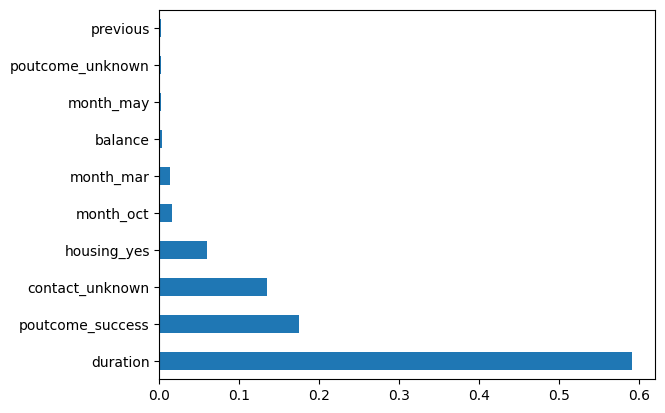

In [12]:
import matplotlib.pyplot as plt

importances = tree_model.feature_importances_
feat_importances = pd.Series(importances, index=X_encoded.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.show()